# Layered Soil System: Parts 1 to 3

This notebook follows the same rough order as the Maple files.

1. Equations of motion
2. Frequency-domain substitution
3. General solutions from `sympy.dsolve`
4. Boundary and interface conditions
5. Matrix form `A C = b`
6. Natural frequencies and mode shapes
7. Frequency response functions


In [2]:
# restart
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from pathlib import Path
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

sp.init_printing(use_unicode=True)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
images_dir = Path("images")
images_dir.mkdir(exist_ok=True)


In [3]:
# problem values defined from the student-ID digits, matching Assignment.2.EQ.py
A, B, C, D, E, F, G = 6, 6, 1, 1, 2, 5, 7

student_digits = {"A": A, "B": B, "C": C, "D": D, "E": E, "F": F, "G": G}

M = (800 + 10 * F) * 1e3
J = 300e6
rho_t = 7850.0
Et = 210e9
xi_t = 0.001
D_out_1 = 9.1
D_inner_1 = 8.96
D_out_2 = 7.1
D_inner_2 = 7.0
F_w = 2e5

H_t = 140 + A
H_w = 30 + F
H1_thickness = 2 + B
H2_thickness = 58 + G
H3_thickness = 38 + F

G1 = (100 + 10 * F) * 1e6
rho1 = 1650.0
eta1 = 1000.0 + 10.0 * C

G2 = (100 + 10 * D) * 1e6
rho2 = 1850.0
eta2 = 1000.0 + 10.0 * E

G3 = (100 + 10 * E) * 1e6
rho3 = 1900.0
eta3 = 1000.0 + 10.0 * D

print("Student-ID digits used in this notebook:")
print(student_digits)
print("\nSoil thicknesses from the assignment definition:")
print(f"H1 = 2 + B = {H1_thickness:.1f} m")
print(f"H2 = 58 + G = {H2_thickness:.1f} m")
print(f"H3 = 38 + F = {H3_thickness:.1f} m")
print("\nMaterial properties used by both the notebook and the script:")
print(f"G1 = {G1:.3e} Pa, rho1 = {rho1:.1f} kg/m^3, eta1 = {eta1:.1f} Ns/m^2")
print(f"G2 = {G2:.3e} Pa, rho2 = {rho2:.1f} kg/m^3, eta2 = {eta2:.1f} Ns/m^2")
print(f"G3 = {G3:.3e} Pa, rho3 = {rho3:.1f} kg/m^3, eta3 = {eta3:.1f} Ns/m^2")


Student-ID digits used in this notebook:
{'A': 6, 'B': 6, 'C': 1, 'D': 1, 'E': 2, 'F': 5, 'G': 7}

Soil thicknesses from the assignment definition:
H1 = 2 + B = 8.0 m
H2 = 58 + G = 65.0 m
H3 = 38 + F = 43.0 m

Material properties used by both the notebook and the script:
G1 = 1.500e+08 Pa, rho1 = 1650.0 kg/m^3, eta1 = 1010.0 Ns/m^2
G2 = 1.100e+08 Pa, rho2 = 1850.0 kg/m^3, eta2 = 1020.0 Ns/m^2
G3 = 1.200e+08 Pa, rho3 = 1900.0 kg/m^3, eta3 = 1010.0 Ns/m^2


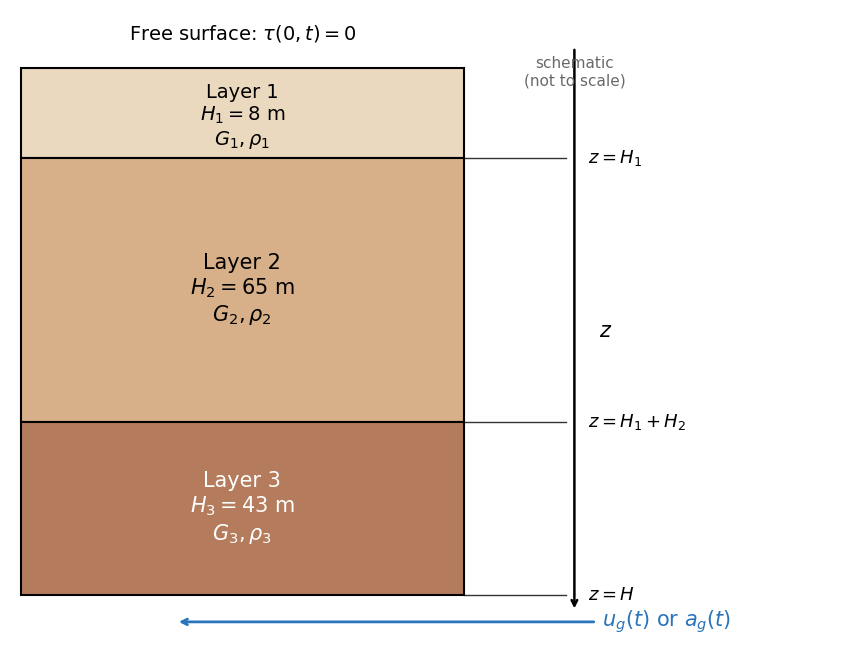

Saved images\q1_layered_soil_profile.png


In [3]:
# schematic profile used for report export
fig_q1, ax = plt.subplots(figsize=(8.6, 6.6))

# schematic heights chosen for readability rather than scale
h1, h2, h3 = 1.1, 3.2, 2.1
x0, w = 0.0, 4.0

y0 = 0.0
y1 = y0 + h1
y2 = y1 + h2
y3 = y2 + h3

colors = ["#ead9bf", "#d7b089", "#b47c5d"]
for yb, h, c in [(y0, h1, colors[0]), (y1, h2, colors[1]), (y2, h3, colors[2])]:
    ax.add_patch(Rectangle((x0, yb), w, h, facecolor=c, edgecolor="black", linewidth=1.5))

ax.text(x0 + w / 2, y0 + h1 / 2 + 0.05, "Layer 1\n$H_1 = 8$ m\n$G_1, \\rho_1$", ha="center", va="center", fontsize=14)
ax.text(x0 + w / 2, y1 + h2 / 2, "Layer 2\n$H_2 = 65$ m\n$G_2, \\rho_2$", ha="center", va="center", fontsize=15)
ax.text(x0 + w / 2, y2 + h3 / 2, "Layer 3\n$H_3 = 43$ m\n$G_3, \\rho_3$", ha="center", va="center", fontsize=15, color="white")

ax.text(x0 + w / 2, y0 - 0.42, "Free surface: $\\tau(0,t)=0$", ha="center", va="center", fontsize=14)

axis_x = x0 + w + 1.0
ax.annotate("", xy=(axis_x, y3 + 0.2), xytext=(axis_x, y0 - 0.25), arrowprops=dict(arrowstyle="->", lw=1.8, color="black"))
ax.text(axis_x + 0.22, (y0 + y3) / 2, "$z$", fontsize=15, va="center")

for yv, label in [(y1, "$z = H_1$"), (y2, "$z = H_1 + H_2$"), (y3, "$z = H$")]:
    ax.plot([x0 + w, axis_x - 0.08], [yv, yv], color="black", lw=1.0, alpha=0.8)
    ax.text(axis_x + 0.12, yv, label, fontsize=13, va="center")

ax.text(x0 + w + 1.0, y0 + 0.25, "schematic\n(not to scale)", fontsize=11, va="bottom", ha="center", color="dimgray")

arrow_y = y3 + 0.33
ax.annotate("", xy=(x0 + 1.4, arrow_y), xytext=(x0 + 5.2, arrow_y), arrowprops=dict(arrowstyle="->", lw=2.0, color="#2a74b9"))
ax.text(x0 + 5.25, arrow_y, "$u_g(t)$ or $a_g(t)$", fontsize=15, va="center", ha="left", color="#2a74b9")

ax.set_xlim(-0.1, 7.4)
ax.set_ylim(y3 + 0.55, y0 - 0.7)
ax.axis("off")
fig_q1.tight_layout()
fig_q1.savefig(images_dir / "q1_layered_soil_profile.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q1_layered_soil_profile.png'}")




## Governing Equations

For one-dimensional SH-wave propagation, the equations of motion in the three layers are

$$
\begin{aligned}
\frac{\partial^2 u_1}{\partial t^2} - c_1^2 \frac{\partial^2 u_1}{\partial z^2} &= 0, \\
\frac{\partial^2 u_2}{\partial t^2} - c_2^2 \frac{\partial^2 u_2}{\partial z^2} &= 0, \\
\frac{\partial^2 u_3}{\partial t^2} - c_3^2 \frac{\partial^2 u_3}{\partial z^2} &= 0,
\end{aligned}
$$

with

$$
c_i = \sqrt{\frac{G_i}{\rho_i}}.
$$

Assume harmonic motion,

$$
u_i(z,t) = U_i(z)e^{i\omega t}.
$$

Then the spatial functions satisfy

$$
\begin{aligned}
U_1''(z) + \left(\frac{\omega}{c_1}\right)^2 U_1(z) &= 0, \\
U_2''(z) + \left(\frac{\omega}{c_2}\right)^2 U_2(z) &= 0, \\
U_3''(z) + \left(\frac{\omega}{c_3}\right)^2 U_3(z) &= 0.
\end{aligned}
$$

Using the same Maple-style assumptions, the boundary and interface conditions are

$$
\begin{aligned}
U_1'(0) &= 0, \\
U_1(H_1) &= U_2(H_1), \\
G_1 U_1'(H_1) &= G_2 U_2'(H_1), \\
U_2(H_1 + H_2) &= U_3(H_1 + H_2), \\
G_2 U_2'(H_1 + H_2) &= G_3 U_3'(H_1 + H_2), \\
U_3(H_1 + H_2 + H_3) &= 0.
\end{aligned}
$$

The interface conditions enforce continuity of displacement and continuity of shear stress $G\,dU/dz$.


In [4]:
# values used in the SH-wave notebook model
# The assignment thicknesses are positive. The notebook uses negative z-coordinates downward.
H_1 = -float(H1_thickness)
H_2 = -float(H2_thickness)
H_3 = -float(H3_thickness)

c_1 = np.sqrt(G1 / rho1)
c_2 = np.sqrt(G2 / rho2)
c_3 = np.sqrt(G3 / rho3)

z0 = 0.0
z1 = H_1
z2 = H_1 + H_2
z3 = H_1 + H_2 + H_3

print(f"c_1 = {c_1:.4f} m/s")
print(f"c_2 = {c_2:.4f} m/s")
print(f"c_3 = {c_3:.4f} m/s")
print(f"layer thicknesses = ({H1_thickness:.1f}, {H2_thickness:.1f}, {H3_thickness:.1f}) m")
print(f"z coordinates: surface = {z0}, interface 1 = {z1}, interface 2 = {z2}, base = {z3}")


c_1 = 301.5113 m/s
c_2 = 243.8431 m/s
c_3 = 251.3123 m/s
layer thicknesses = (8.0, 65.0, 43.0) m
z coordinates: surface = 0.0, interface 1 = -8.0, interface 2 = -73.0, base = -116.0


**Time-domain equations of motion**

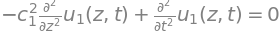

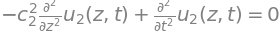

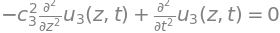

**Frequency-domain ODEs**

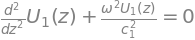

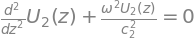

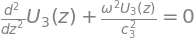

**General solutions from `sympy.dsolve`**

In [5]:
# symbolic derivation, matching the Maple workflow
z, t = sp.symbols("z t", real=True)
omega_sym = sp.symbols("omega", real=True)
H1_sym, H2_sym, H3_sym = sp.symbols("H_1 H_2 H_3", real=True)
c1_sym, c2_sym, c3_sym = sp.symbols("c_1 c_2 c_3", positive=True, real=True)
G1_sym, G2_sym, G3_sym = sp.symbols("G_1 G_2 G_3", positive=True, real=True)

u_1 = sp.Function("u_1")
u_2 = sp.Function("u_2")
u_3 = sp.Function("u_3")

Layer_1 = sp.Eq(sp.diff(u_1(z, t), t, 2) - c1_sym**2 * sp.diff(u_1(z, t), z, 2), 0)
Layer_2 = sp.Eq(sp.diff(u_2(z, t), t, 2) - c2_sym**2 * sp.diff(u_2(z, t), z, 2), 0)
Layer_3 = sp.Eq(sp.diff(u_3(z, t), t, 2) - c3_sym**2 * sp.diff(u_3(z, t), z, 2), 0)

U_1 = sp.Function("U_1")
U_2 = sp.Function("U_2")
U_3 = sp.Function("U_3")

Layer_1_fd = sp.Eq(sp.diff(U_1(z), z, 2) + (omega_sym / c1_sym)**2 * U_1(z), 0)
Layer_2_fd = sp.Eq(sp.diff(U_2(z), z, 2) + (omega_sym / c2_sym)**2 * U_2(z), 0)
Layer_3_fd = sp.Eq(sp.diff(U_3(z), z, 2) + (omega_sym / c3_sym)**2 * U_3(z), 0)

C1, C2, C3, C4, C5, C6 = sp.symbols("C1 C2 C3 C4 C5 C6")
const_vector = [C1, C2, C3, C4, C5, C6]

sol_1 = sp.dsolve(Layer_1_fd).rhs.subs({sp.Symbol("C1"): C5, sp.Symbol("C2"): C6})
sol_2 = sp.dsolve(Layer_2_fd).rhs.subs({sp.Symbol("C1"): C3, sp.Symbol("C2"): C4})
sol_3 = sp.dsolve(Layer_3_fd).rhs.subs({sp.Symbol("C1"): C1, sp.Symbol("C2"): C2})

display(Markdown("**Time-domain equations of motion**"))
display(Layer_1)
display(Layer_2)
display(Layer_3)

display(Markdown("**Frequency-domain ODEs**"))
display(Layer_1_fd)
display(Layer_2_fd)
display(Layer_3_fd)

display(Markdown("**General solutions from `sympy.dsolve`**"))
display(sp.Eq(U_1(z), sol_1))
display(sp.Eq(U_2(z), sol_2))
display(sp.Eq(U_3(z), sol_3))


## 2. Boundary Conditions and Matrix Form

The constant ordering is kept exactly as in the Maple file:

$$
\mathbf{C} = [C_1, C_2, C_3, C_4, C_5, C_6]^T.
$$

The symbolic matrix is obtained directly from the six homogeneous equations using `sympy.linear_eq_to_matrix`.


In [6]:
# boundary and interface conditions
BC_top = sp.Eq(sp.diff(sol_1, z).subs(z, 0), 0)

IC_1 = sp.Eq(sol_1.subs(z, H1_sym), sol_2.subs(z, H1_sym))
IC_2 = sp.Eq(G1_sym * sp.diff(sol_1, z).subs(z, H1_sym), G2_sym * sp.diff(sol_2, z).subs(z, H1_sym))

IC_3 = sp.Eq(sol_2.subs(z, H1_sym + H2_sym), sol_3.subs(z, H1_sym + H2_sym))
IC_4 = sp.Eq(G2_sym * sp.diff(sol_2, z).subs(z, H1_sym + H2_sym), G3_sym * sp.diff(sol_3, z).subs(z, H1_sym + H2_sym))

BC_bot = sp.Eq(sol_3.subs(z, H1_sym + H2_sym + H3_sym), 0)

eqs = [BC_top, IC_1, IC_2, IC_3, IC_4, BC_bot]
eq_exprs = [sp.expand(eq.lhs - eq.rhs) for eq in eqs]
A_sym, b_sym = sp.linear_eq_to_matrix(eq_exprs, const_vector)

display(Markdown("**Boundary and interface conditions**"))
for eq in eqs:
    display(eq)

display(Markdown("**Coefficient matrix $A(\\omega)$**"))
display(A_sym)

display(Markdown("**Right-hand side vector $b$**"))
display(b_sym)


**Boundary and interface conditions**

**Coefficient matrix $A(\omega)$**

âŽ¡                                                                              â†ª
âŽ¢              0                           0                          0        â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                   âŽ›Hâ‚â‹…â”‚Ï‰â”‚âŽž   â†ª
âŽ¢              0                           0                    -sinâŽœâ”€â”€â”€â”€â”€â”€âŽŸ   â†ª
âŽ¢                                                                   âŽ  câ‚‚  âŽ    â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                  âŽ›Hâ‚â‹…â”‚Ï‰â”‚âŽž    â†ª
âŽ¢                                                           -Gâ‚‚â‹…cosâŽœâ”€â”€â”€â”€â”€â”€âŽŸâ‹…â”‚Ï‰ â†ª
âŽ¢                                                                  âŽ  câ‚

**Right-hand side vector $b$**

âŽ¡0âŽ¤
âŽ¢ âŽ¥
âŽ¢0âŽ¥
âŽ¢ âŽ¥
âŽ¢0âŽ¥
âŽ¢ âŽ¥
âŽ¢0âŽ¥
âŽ¢ âŽ¥
âŽ¢0âŽ¥
âŽ¢ âŽ¥
âŽ£0âŽ¦

In [7]:
# numeric matrix obtained from the symbolic matrix
parameter_subs = {
    H1_sym: H_1,
    H2_sym: H_2,
    H3_sym: H_3,
    c1_sym: c_1,
    c2_sym: c_2,
    c3_sym: c_3,
    G1_sym: G1,
    G2_sym: G2,
    G3_sym: G3,
}

A_num_sym = A_sym.subs(parameter_subs)
A_func = sp.lambdify(omega_sym, A_num_sym, "numpy")
const_names = [str(item) for item in const_vector]

def build_matrix(omega):
    return np.array(A_func(omega), dtype=float)

def det_A(omega):
    return float(np.linalg.det(build_matrix(omega)))

print("Matrix size:", build_matrix(10.0).shape)
print("Constant order:", const_names)


Matrix size: (6, 6)
Constant order: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']


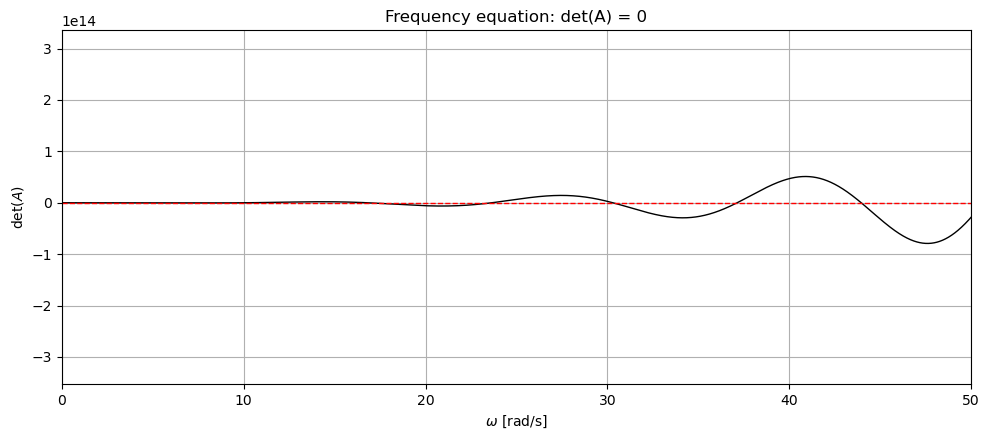

Saved images\q2_frequency_equation.png


First 10 natural frequencies in rad/s:
mode  1: omega =  3.41964 rad/s, f = 0.54425 Hz
mode  2: omega = 10.07663 rad/s, f = 1.60374 Hz
mode  3: omega = 16.80455 rad/s, f = 2.67453 Hz
mode  4: omega = 23.64545 rad/s, f = 3.76329 Hz
mode  5: omega = 30.29954 rad/s, f = 4.82232 Hz
mode  6: omega = 37.13594 rad/s, f = 5.91037 Hz
mode  7: omega = 43.95543 rad/s, f = 6.99572 Hz
mode  8: omega = 50.65300 rad/s, f = 8.06167 Hz
mode  9: omega = 57.56232 rad/s, f = 9.16133 Hz
mode 10: omega = 64.31951 rad/s, f = 10.23677 Hz


In [8]:
# finding eigen frequencies from det(A) = 0
omega_scan = np.linspace(0.1, 80.0, 12000)
det_scan = np.array([det_A(omega) for omega in omega_scan])

fig_freq, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(omega_scan, det_scan, color="black", lw=1.0)
ax.axhline(0.0, color="red", lw=1.0, ls="--")
ax.set_xlim(0.0, 50.0)
ax.set_xlabel(r"$\omega$ [rad/s]")
ax.set_ylabel(r"det$(A)$")
ax.set_title("Frequency equation: det(A) = 0")
fig_freq.tight_layout()
fig_freq.savefig(images_dir / "q2_frequency_equation.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q2_frequency_equation.png'}")

def bisection_root(fun, a, b, n_iter=80):
    fa = fun(a)
    fb = fun(b)
    if np.sign(fa) == np.sign(fb):
        raise ValueError("Bisection interval does not bracket a root.")

    for _ in range(n_iter):
        m = 0.5 * (a + b)
        fm = fun(m)
        if np.sign(fa) == np.sign(fm):
            a, fa = m, fm
        else:
            b, fb = m, fm

    return 0.5 * (a + b)

def find_natural_frequencies(omega_grid, n_modes=10):
    det_values = np.array([det_A(omega) for omega in omega_grid])
    sign_changes = np.where(np.sign(det_values[:-1]) != np.sign(det_values[1:]))[0]

    omegas = []
    for idx in sign_changes:
        omega_left = omega_grid[idx]
        omega_right = omega_grid[idx + 1]
        omegas.append(bisection_root(det_A, omega_left, omega_right))
        if len(omegas) == n_modes:
            break

    return np.array(omegas)

omega_n = find_natural_frequencies(omega_scan, n_modes=10)
f_n = omega_n / (2.0 * np.pi)

print("First 10 natural frequencies in rad/s:")
for i, omega in enumerate(omega_n, start=1):
    print(f"mode {i:2d}: omega = {omega:8.5f} rad/s, f = {f_n[i - 1]:7.5f} Hz")


In [9]:
# solve for the first mode constants with C6 = 1
omega1 = omega_n[0]
A1 = build_matrix(omega1)
b1 = np.zeros(6)

C_rest = np.linalg.solve(A1[:5, :5], -A1[:5, 5])
C_mode1 = np.concatenate([C_rest, [1.0]])
eq_mode = A1 @ C_mode1 - b1

print(f"omega1 = {omega1:.8f} rad/s")
for name, value in zip(const_names, C_mode1):
    print(f"{name} = {value:.8f}")

print("\nResidual A1 @ C - b1:")
print(eq_mode)


omega1 = 3.41964196 rad/s
C1 = -0.00733766
C2 = 0.96144369
C3 = -0.01219854
C4 = 1.00081283
C5 = -0.00000000
C6 = 1.00000000

Residual A1 @ C - b1:
[ 0.00000000e+00 -4.44522891e-17  0.00000000e+00  0.00000000e+00
  0.00000000e+00  9.71445147e-17]


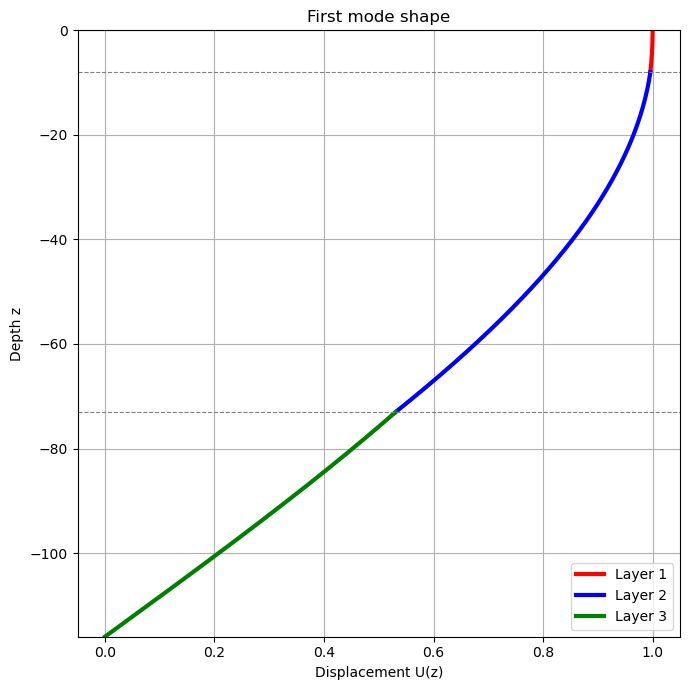

Saved images\q2_first_mode_shape.png


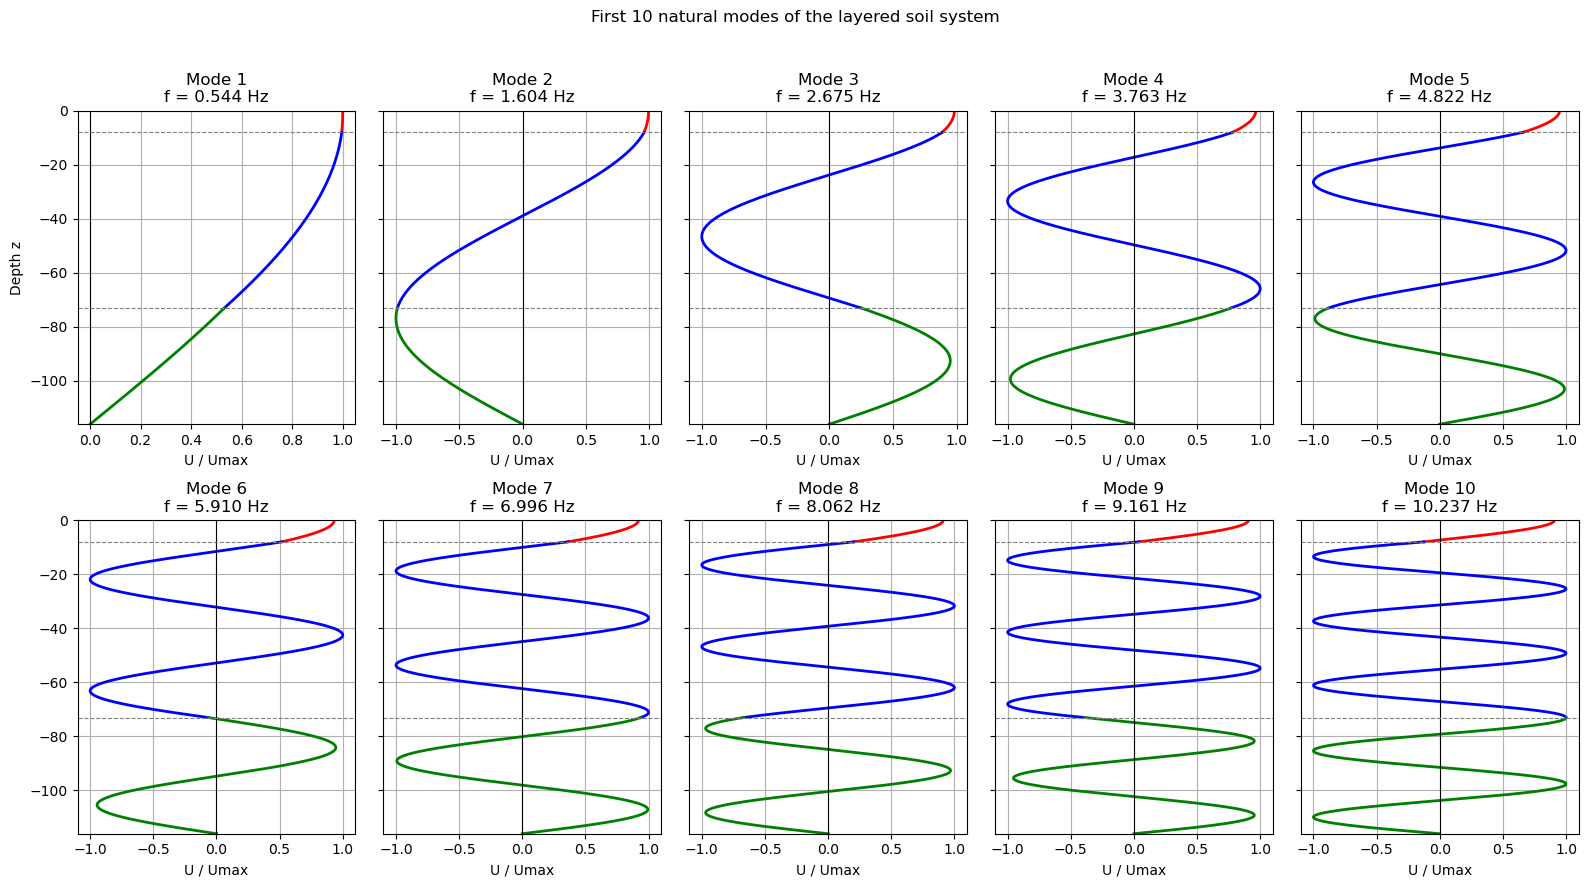

Saved images\q2_first_10_modes.png


In [10]:
def solve_mode_constants(omega):
    A = build_matrix(omega)
    C_rest = np.linalg.solve(A[:5, :5], -A[:5, 5])
    return np.concatenate([C_rest, [1.0]])

def layer_mode_shapes(omega, C, n_points=250):
    C1_val, C2_val, C3_val, C4_val, C5_val, C6_val = C

    z_layer1 = np.linspace(z1, z0, n_points)
    z_layer2 = np.linspace(z2, z1, n_points)
    z_layer3 = np.linspace(z3, z2, n_points)

    U1 = C5_val * np.sin(omega * z_layer1 / c_1) + C6_val * np.cos(omega * z_layer1 / c_1)
    U2 = C3_val * np.sin(omega * z_layer2 / c_2) + C4_val * np.cos(omega * z_layer2 / c_2)
    U3 = C1_val * np.sin(omega * z_layer3 / c_3) + C2_val * np.cos(omega * z_layer3 / c_3)

    return z_layer1, U1, z_layer2, U2, z_layer3, U3

z_layer1, U1, z_layer2, U2, z_layer3, U3 = layer_mode_shapes(omega1, C_mode1)

fig_mode1, ax = plt.subplots(figsize=(7, 7))
ax.plot(U1, z_layer1, color="red", lw=3, label="Layer 1")
ax.plot(U2, z_layer2, color="blue", lw=3, label="Layer 2")
ax.plot(U3, z_layer3, color="green", lw=3, label="Layer 3")
ax.axhline(z1, color="gray", lw=0.8, ls="--")
ax.axhline(z2, color="gray", lw=0.8, ls="--")
ax.set_xlabel("Displacement U(z)")
ax.set_ylabel("Depth z")
ax.set_title("First mode shape")
ax.legend()
ax.set_ylim(z3, z0)
fig_mode1.tight_layout()
fig_mode1.savefig(images_dir / "q2_first_mode_shape.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q2_first_mode_shape.png'}")

fig_modes, axes = plt.subplots(2, 5, figsize=(16, 9), sharey=True)
axes = axes.ravel()

for i, omega in enumerate(omega_n):
    C_mode = solve_mode_constants(omega)
    z_layer1, U1, z_layer2, U2, z_layer3, U3 = layer_mode_shapes(omega, C_mode)

    U_all = np.concatenate([U3, U2, U1])
    scale = np.max(np.abs(U_all))
    U1 = U1 / scale
    U2 = U2 / scale
    U3 = U3 / scale

    axes[i].plot(U1, z_layer1, color="red", lw=2)
    axes[i].plot(U2, z_layer2, color="blue", lw=2)
    axes[i].plot(U3, z_layer3, color="green", lw=2)
    axes[i].axvline(0.0, color="black", lw=0.8)
    axes[i].axhline(z1, color="gray", lw=0.8, ls="--")
    axes[i].axhline(z2, color="gray", lw=0.8, ls="--")
    axes[i].set_title(f"Mode {i + 1}\nf = {f_n[i]:.3f} Hz")
    axes[i].set_xlabel("U / Umax")
    axes[i].set_ylim(z3, z0)

axes[0].set_ylabel("Depth z")
fig_modes.suptitle("First 10 natural modes of the layered soil system", y=0.98)
fig_modes.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
fig_modes.savefig(images_dir / "q2_first_10_modes.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q2_first_10_modes.png'}")


## Effect of Soil Damping on Natural Frequencies and Modes

If soil damping is included, the shear modulus becomes complex, for example

$$
G_i^* = G_i + i\omega\eta_i.
$$

As a result, the eigenvalue problem is no longer purely real. The main effects are:

- The natural frequencies become complex-valued. For light damping, the real part gives the damped oscillation frequency and is usually slightly lower than the undamped natural frequency.
- The imaginary part of the eigenvalue represents decay in time, so free vibrations are no longer persistent standing waves but exponentially decaying oscillations.
- The mode shapes become complex-valued rather than purely real. This means that different depths can have both amplitude differences and phase differences.
- For small damping, the shapes of the modes remain close to the undamped ones, but near resonance they are smoother and less sharply defined.
- In the frequency response, damping reduces and broadens the resonance peaks, and the abrupt phase jumps of the undamped system become smooth transitions.

Therefore, including soil damping does not completely change the modal pattern for small damping, but it introduces decay, slight downward shifts of the natural frequencies, and complex mode shapes with depth-dependent phase lag.


## 3. Frequency Response Functions

For the forced-response problem, the same equations of motion and the same layer-wise solutions are used. The only change is the bedrock boundary condition.

Assume the bedrock acceleration is prescribed as

$$
a_g(t) = a_0 e^{i\omega t}.
$$

Since acceleration and displacement are related by $a = -\omega^2 U e^{i\omega t}$, the corresponding displacement amplitude at the bedrock is

$$
U_g = -\frac{a_0}{\omega^2}.
$$

Therefore the bottom boundary condition becomes

$$
U_3(H_1 + H_2 + H_3) = -\frac{a_0}{\omega^2}.
$$

The displacement FRF can then be written as

$$
H(z,\omega) = \frac{U(z)}{U_g} = -\frac{\omega^2 U(z)}{a_0}.
$$

So the same complex ratio also gives the acceleration FRF.


In [11]:
# forced-response matrix, following the Maple part 3 setup
a0_sym = sp.symbols("a_0", real=True, nonzero=True)

BC_bot_forced = sp.Eq(sol_3.subs(z, H1_sym + H2_sym + H3_sym), -a0_sym / omega_sym**2)
eqs_frf = [BC_top, IC_1, IC_2, IC_3, IC_4, BC_bot_forced]
eq_exprs_frf = [sp.expand(eq.lhs - eq.rhs) for eq in eqs_frf]
A_frf_sym, b_frf_sym = sp.linear_eq_to_matrix(eq_exprs_frf, const_vector)

display(Markdown("**Forced bedrock boundary condition**"))
display(BC_bot_forced)

display(Markdown("**Coefficient matrix for the forced problem**"))
display(A_frf_sym)

display(Markdown("**Right-hand side vector for the forced problem**"))
display(b_frf_sym)

print("A_frf is identical to the homogeneous A:", sp.simplify(A_frf_sym - A_sym) == sp.zeros(6))


**Forced bedrock boundary condition**

**Coefficient matrix for the forced problem**

âŽ¡                                                                              â†ª
âŽ¢              0                           0                          0        â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                   âŽ›Hâ‚â‹…â”‚Ï‰â”‚âŽž   â†ª
âŽ¢              0                           0                    -sinâŽœâ”€â”€â”€â”€â”€â”€âŽŸ   â†ª
âŽ¢                                                                   âŽ  câ‚‚  âŽ    â†ª
âŽ¢                                                                              â†ª
âŽ¢                                                                  âŽ›Hâ‚â‹…â”‚Ï‰â”‚âŽž    â†ª
âŽ¢                                                           -Gâ‚‚â‹…cosâŽœâ”€â”€â”€â”€â”€â”€âŽŸâ‹…â”‚Ï‰ â†ª
âŽ¢                                                                  âŽ  câ‚

**Right-hand side vector for the forced problem**

âŽ¡ 0  âŽ¤
âŽ¢    âŽ¥
âŽ¢ 0  âŽ¥
âŽ¢    âŽ¥
âŽ¢ 0  âŽ¥
âŽ¢    âŽ¥
âŽ¢ 0  âŽ¥
âŽ¢    âŽ¥
âŽ¢ 0  âŽ¥
âŽ¢    âŽ¥
âŽ¢-aâ‚€ âŽ¥
âŽ¢â”€â”€â”€â”€âŽ¥
âŽ¢  2 âŽ¥
âŽ£ Ï‰  âŽ¦

A_frf is identical to the homogeneous A: True


In [12]:
# numerical FRF functions based on the symbolic matrix and right-hand side
A_frf_num_sym = A_frf_sym.subs(parameter_subs)
b_frf_num_sym = b_frf_sym.subs(parameter_subs)

A_frf_func = sp.lambdify(omega_sym, A_frf_num_sym, "numpy")
b_frf_func = sp.lambdify((omega_sym, a0_sym), b_frf_num_sym, "numpy")

def solve_forced_constants(omega, a0=1.0):
    A = np.array(A_frf_func(omega), dtype=complex)
    b = np.array(b_frf_func(omega, a0), dtype=complex).reshape(-1)
    return np.linalg.solve(A, b)

def evaluate_displacement(omega, C, z_value):
    C1_val, C2_val, C3_val, C4_val, C5_val, C6_val = C

    if z_value > z1:
        return C5_val * np.sin(omega * z_value / c_1) + C6_val * np.cos(omega * z_value / c_1)
    if z_value > z2:
        return C3_val * np.sin(omega * z_value / c_2) + C4_val * np.cos(omega * z_value / c_2)
    return C1_val * np.sin(omega * z_value / c_3) + C2_val * np.cos(omega * z_value / c_3)

def displacement_frf(omega, z_value, a0=1.0):
    C = solve_forced_constants(omega, a0=a0)
    U_local = evaluate_displacement(omega, C, z_value)
    U_ground = -a0 / omega**2
    return U_local / U_ground

def acceleration_frf(omega, z_value, a0=1.0):
    C = solve_forced_constants(omega, a0=a0)
    U_local = evaluate_displacement(omega, C, z_value)
    return -omega**2 * U_local / a0

omega_test = 12.0
print("displacement FRF equals acceleration FRF at the same location:")
print(np.allclose(displacement_frf(omega_test, z0), acceleration_frf(omega_test, z0)))


displacement FRF equals acceleration FRF at the same location:
True


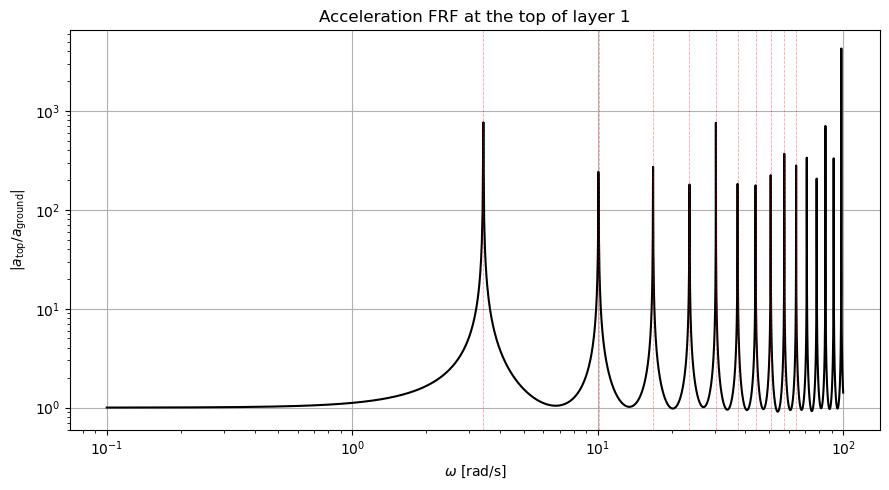

Saved images\q3_surface_acceleration_frf.png


In [13]:
# Maple-style plot: acceleration FRF at the top of layer 1
omega_frf = np.linspace(0.1, 100.0, 4000)
H_surface = np.array([acceleration_frf(omega, z0) for omega in omega_frf])
H_top_layer3 = np.array([acceleration_frf(omega, z2) for omega in omega_frf])

fig_surface_frf, ax = plt.subplots(figsize=(9, 5))
ax.loglog(omega_frf, np.abs(H_surface), color="black", lw=1.5)
for omega in omega_n:
    ax.axvline(omega, color="red", lw=0.6, ls="--", alpha=0.35)
ax.set_xlabel(r"$\omega$ [rad/s]")
ax.set_ylabel(r"$|a_{\mathrm{top}}/a_{\mathrm{ground}}|$")
ax.set_title("Acceleration FRF at the top of layer 1")
fig_surface_frf.tight_layout()
fig_surface_frf.savefig(images_dir / "q3_surface_acceleration_frf.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q3_surface_acceleration_frf.png'}")


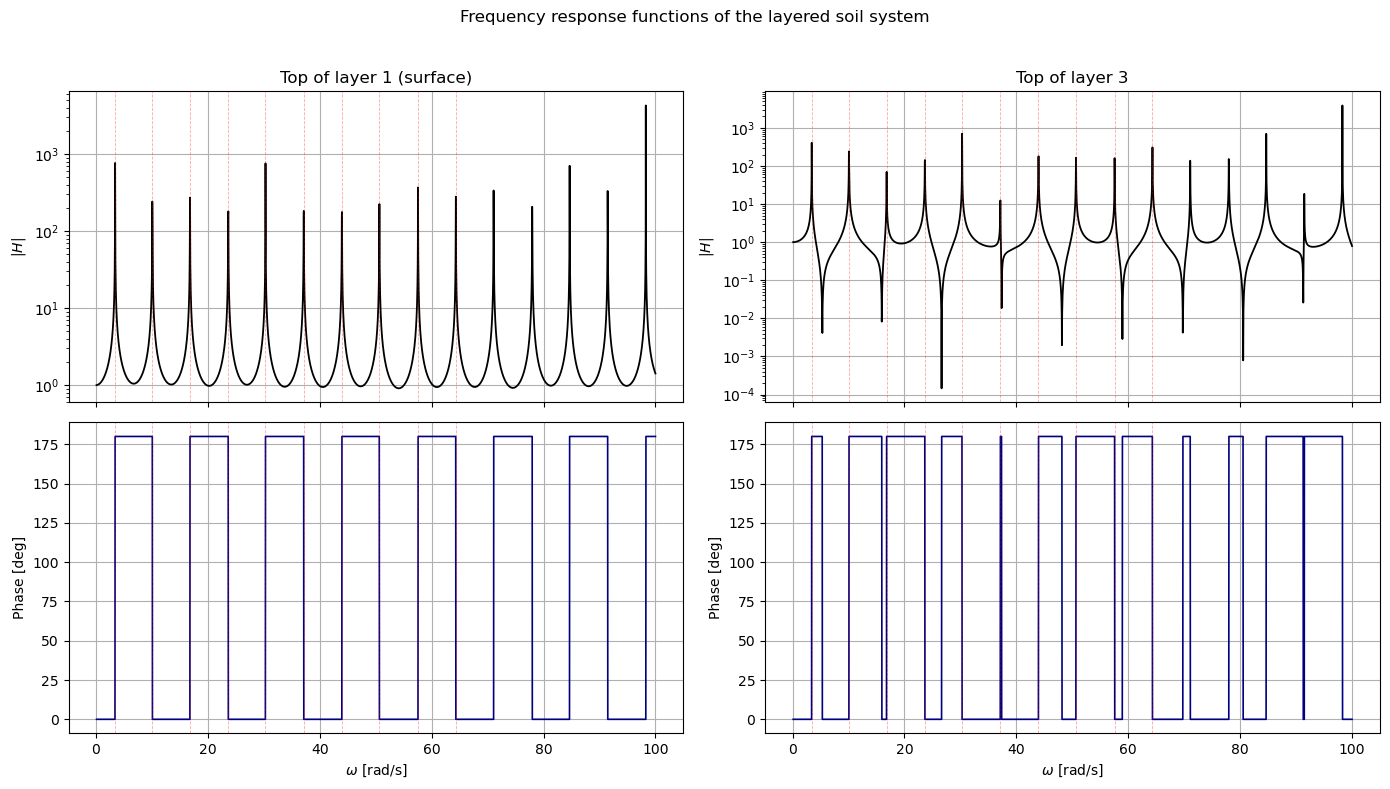

Saved images\q3_frf_amplitude_phase.png


In [14]:
# amplitude and phase at the top of layer 3 and the top of layer 1
phase_surface = np.angle(H_surface, deg=True)
phase_top_layer3 = np.angle(H_top_layer3, deg=True)

fig_frf, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

axes[0, 0].plot(omega_frf, np.abs(H_surface), color="black", lw=1.3)
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel(r"$|H|$")
axes[0, 0].set_title("Top of layer 1 (surface)")

axes[0, 1].plot(omega_frf, np.abs(H_top_layer3), color="black", lw=1.3)
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel(r"$|H|$")
axes[0, 1].set_title("Top of layer 3")

axes[1, 0].plot(omega_frf, phase_surface, color="navy", lw=1.2)
axes[1, 0].set_xlabel(r"$\omega$ [rad/s]")
axes[1, 0].set_ylabel("Phase [deg]")

axes[1, 1].plot(omega_frf, phase_top_layer3, color="navy", lw=1.2)
axes[1, 1].set_xlabel(r"$\omega$ [rad/s]")
axes[1, 1].set_ylabel("Phase [deg]")

for ax in axes.ravel():
    for omega in omega_n:
        ax.axvline(omega, color="red", lw=0.6, ls="--", alpha=0.35)

fig_frf.suptitle("Frequency response functions of the layered soil system", y=0.98)
fig_frf.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
fig_frf.savefig(images_dir / "q3_frf_amplitude_phase.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Saved {images_dir / 'q3_frf_amplitude_phase.png'}")


## Interpretation of Part 3

- The amplitude at the surface is larger because the wave has passed through all three layers and is additionally amplified by reflections at the free surface.
- The amplitude at the top of layer 3 is usually smaller because this point is closer to the imposed bedrock motion and does not include the full amplification of the upper layers.
- In the undamped model used here, the FRF is real-valued away from numerical roundoff, so the phase is mostly $0^\circ$ or $180^\circ$.
- The phase tells whether the local response is in phase or out of phase with the harmonic bedrock input. The sharp jumps occur when the response changes sign across resonances or anti-resonances.
- If damping is added, these abrupt flips become smooth phase transitions and the resonant peaks become finite and broader.
